In [ ]:
from default_globals import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from utils import make_nice_plots
from scipy.stats import binom
import glob
import h5py
from redshift_utils import *
from scipy.integrate import romb
from scipy.special import erf
from priors import *
import pandas as pd
import json
from ligo.skymap.io.fits import read_sky_map
from tqdm import tqdm
from utils import *

make_nice_plots()


/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# zcuts=$(python -c "import numpy as np; print(' '.join(map(str, np.linspace(0, 2, 50))))")
# agn_errs=$(python -c "import numpy as np; print(' '.join(map(str, np.geomspace(0.001, 1, 50)[30:])))")

print(np.linspace(0, 2, 50))
print(np.geomspace(0.001, 1, 50)[28:])
print(len(np.geomspace(0.001, 1, 50)[30:]))
print(50 * 20)

[0.         0.04081633 0.08163265 0.12244898 0.16326531 0.20408163
 0.24489796 0.28571429 0.32653061 0.36734694 0.40816327 0.44897959
 0.48979592 0.53061224 0.57142857 0.6122449  0.65306122 0.69387755
 0.73469388 0.7755102  0.81632653 0.85714286 0.89795918 0.93877551
 0.97959184 1.02040816 1.06122449 1.10204082 1.14285714 1.18367347
 1.2244898  1.26530612 1.30612245 1.34693878 1.3877551  1.42857143
 1.46938776 1.51020408 1.55102041 1.59183673 1.63265306 1.67346939
 1.71428571 1.75510204 1.79591837 1.83673469 1.87755102 1.91836735
 1.95918367 2.        ]
[0.05179475 0.05963623 0.06866488 0.07906043 0.09102982 0.10481131
 0.12067926 0.13894955 0.15998587 0.184207   0.21209509 0.24420531
 0.28117687 0.32374575 0.37275937 0.42919343 0.49417134 0.5689866
 0.65512856 0.75431201 0.86851137 1.        ]
20
1000


In [ ]:
def run2colorsize(run):
    if run == 'O1':
        color = 'blue'
        s = 50
    elif run == 'O2':
        color = 'red'
        s = 25
    elif run == 'O3':
        color = 'green'
        s = 5
    elif run == 'O4':
        color='black'
        s = 1
    return color, s


In [4]:
# # Get skymap stats

# os.environ["OMP_NUM_THREADS"] = "1"

# ROOT_DIRECTORY = '/home/lucas/Documents/PhD/mock_gws_nonuniform_True_zmax_10_zcut_1_LVKvols'
# TYPES = ['agn', 'alt']
# DIRECTORY_IDS = np.arange(1, 201, 1)

# for DIRECTORY_ID in DIRECTORY_IDS:
#     for TYPE in TYPES:

#         SKYMAP_DIR = f'{ROOT_DIRECTORY}/output_run_{DIRECTORY_ID}/skymaps/{TYPE}/'
#         WRITE_DIR = f'{ROOT_DIRECTORY}/output_run_{DIRECTORY_ID}/skymap_stats/{TYPE}/'
#         if not os.path.isdir(WRITE_DIR):
#             os.makedirs(WRITE_DIR)

#         gw_fnames = glob.glob(SKYMAP_DIR + 'skymap*.fits.gz')
#         for i, filename in tqdm(enumerate(gw_fnames), total=len(gw_fnames)):
#             id = filename[-13:-8]
#             os.system(f'ligo-skymap-stats {filename} -p 90 --cosmology --output {f"{WRITE_DIR}{id}.dat"}')



In [18]:
ROOT_DIRECTORY = '/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_3000_zmax_10_zcut_1.0_LVKvols'

redshift_errors = []
for run_directory in tqdm( glob.glob(f'{ROOT_DIRECTORY}/output_run_*') ):

    for postsamp_file in glob.glob(f'{run_directory}/posterior_samples/*.h5'):

        with h5py.File(postsamp_file, 'r') as f:
            for key in list(f.keys()):
                redshift_samples = f[key]['mock']['posterior_samples']['redshift']
                redshift_errors.append((np.quantile(redshift_samples, 0.84) - np.quantile(redshift_samples, 0.16)) / 2)


100%|██████████| 200/200 [00:16<00:00, 11.77it/s]


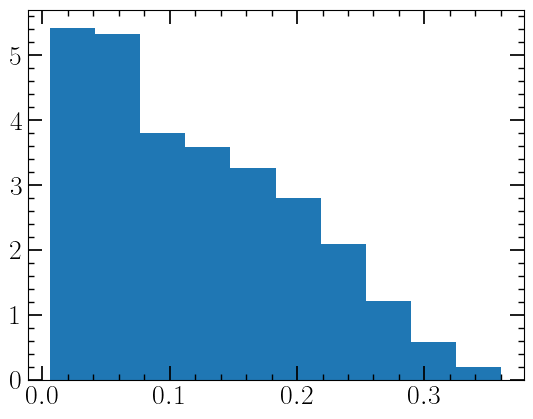

0.1082219311281771 0.0723047367451849 0.10443017584895764


In [22]:
plt.figure()
plt.hist(redshift_errors, density=True)
plt.show()

print(np.median(redshift_errors), np.median(redshift_errors) - np.quantile(redshift_errors, 0.16), np.quantile(redshift_errors, 0.84) - np.median(redshift_errors))


In [7]:
# ROOT_DIRECTORY = '/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_3000_zmax_10_zcut_1.0_LVKvols'
# TYPES = ['agn', 'alt']
# DIRECTORY_IDS = np.arange(1, 201, 1)


# ratios = []
# log_ratios = []
# areas = []
# mock_meandls = []
# mock_v90s = []
# samped_v90s = []
# for DIRECTORY_ID in DIRECTORY_IDS:
#     for TYPE in TYPES:

#         COORDS_FILE = f'{ROOT_DIRECTORY}/output_run_{DIRECTORY_ID}/true_gw_coords/{TYPE}/true_r_theta_phi.txt'
#         dat = np.genfromtxt(COORDS_FILE, delimiter=',')
#         all_ids, all_v90s = dat[:,0].astype(int), dat[:,-1]

#         STATS_DIR = f'{ROOT_DIRECTORY}/output_run_{DIRECTORY_ID}/skymap_stats/{TYPE}/'

#         stats_fnames = glob.glob(STATS_DIR + '*.dat')
#         for i, filename in tqdm(enumerate(stats_fnames), total=len(stats_fnames)):
#             id = int(filename[-9:-4])

#             sampled_v90 = all_v90s[all_ids == id][0]

#             statsdat = np.genfromtxt(filename)
#             stats_v90 = statsdat[1][-1]
#             stats_a90 = statsdat[1][-3]

#             # print(sampled_v90, stats_v90)
#             mock_meandls.append(statsdat[1][2])
#             samped_v90s.append(sampled_v90)
#             mock_v90s.append(stats_v90)
#             areas.append(stats_a90)
#             ratios.append(sampled_v90 / stats_v90)
#             log_ratios.append(np.log10(sampled_v90) / np.log10(stats_v90))


In [8]:
real_meandls = []
real_areas = []
real_v90s = []
real_fnames = []
for fname in glob.glob('/home/lucas/Documents/PhD/realstats/*.dat'):
    real_fnames.append(fname)
    
    statsdat = np.genfromtxt(fname)
    stats_v90 = statsdat[1][-1]
    stats_a90 = statsdat[1][-3]

    real_meandls.append(statsdat[1][2])
    real_areas.append(stats_a90)
    real_v90s.append(stats_v90)

mask = ~np.isinf(real_v90s)
real_v90s = np.array(real_v90s)[mask]
real_areas = np.array(real_areas)[mask]
real_meandls = np.array(real_meandls)[mask]
real_fnames = np.array(real_fnames)[mask]


In [9]:
from scipy.special import gammaincinv

BATCH = int(1e5)
V90_CDF = '/home/lucas/Documents/PhD/darksirenpop/v90_cdf_LVK.npy'
FIXED_VOL = False  # float or False

ZMIN = 1e-6
ZMAX = 10  # p_rate(z > ZMAX) = 0

F_AGN_TRUE = np.random.uniform()
print(F_AGN_TRUE, 'FAGN')
AGN_DIST_DIR = '/home/lucas/Documents/PhD/darksirenpop/agn_distribution'
AGN_ZPRIOR = '46.5_kulkarni'

filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
print(f'Loading AGN redshift distribution from file: {filename}')
z, n = np.load(filename)
AGN_DIST = interp1d(z, n, bounds_error=False, fill_value=0)

Z_GRID = np.linspace(0, ZMAX, 1024+1)
Z_DIST_AGN = lambda z: time_dilation_correction(z) * z_cut(z, zcut=ZMAX) * AGN_DIST(z) / romb(time_dilation_correction(z) * z_cut(z, zcut=ZMAX) * AGN_DIST(z), dx=np.diff(z)[0])
Z_DIST_ALT = lambda z: time_dilation_correction(z) * z_cut(z, zcut=ZMAX) * merger_rate_madau_dickinson(z) * uniform_comoving_prior(z) / romb(time_dilation_correction(z) * z_cut(z, zcut=ZMAX) * merger_rate_madau_dickinson(z) * uniform_comoving_prior(z), dx=np.diff(z)[0])


altnorm = romb(time_dilation_correction(Z_GRID) * z_cut(Z_GRID, zcut=ZMAX) * merger_rate_madau_dickinson(Z_GRID) * uniform_comoving_prior(Z_GRID), dx=np.diff(Z_GRID)[0])
Z_DIST_ALT_NORM = lambda z: time_dilation_correction(z) * z_cut(z, zcut=ZMAX) * merger_rate_madau_dickinson(z) * uniform_comoving_prior(z) / altnorm

COMDIST_MIN = COSMO.comoving_distance(ZMIN).value
COMDIST_MAX = COSMO.comoving_distance(ZMAX).value  # Maximum comoving distance in Mpc


def sample_v90(n=BATCH, factor=1):
    '''Inverse CDF sampling of observed distribution of log10 v90 in cMpc'''
    cdf_vals, x_grid = np.load(V90_CDF)
    inv_cdf = interp1d(cdf_vals, x_grid)
    u = np.random.rand(n)
    return 10**inv_cdf(u) / factor


def v90_to_sigma(v90):
    '''Going from the 90th percentile radius to sigma using the Maxwell-Boltzmann distribution.'''
    r90 = (v90 * 3 / (4 * np.pi))**(1/3)
    return r90 / np.sqrt(2 * gammaincinv(3/2, 0.9))


def make_real_gw_positions(n=BATCH, kind=None):

    if kind == None:
        true_rcom, true_theta, true_phi = uniform_shell_sampler(COMDIST_MIN, COMDIST_MAX, n)
    
    elif kind == 'agn':
        true_z = sample_from_distribution(Z_DIST_AGN, Z_GRID, n_samples=n)

        if len(true_z) == 0:
            true_rcom = np.array([])
        else:
            true_rcom = COSMO.comoving_distance(true_z).value

        true_theta, true_phi = sample_spherical_angles(n_samps=n)
    
    elif kind == 'alt':
        true_z = sample_from_distribution(Z_DIST_ALT, Z_GRID, n_samples=n)

        if len(true_z) == 0:
            true_rcom = np.array([])
        else:
            true_rcom = COSMO.comoving_distance(true_z).value
            
        true_theta, true_phi = sample_spherical_angles(n_samps=n)

    else:
        sys.exit(f'Function does not support argument value kind == {kind}. Use "alt", "agn" or None.')        

    true_x, true_y, true_z = spherical2cartesian(true_rcom, true_theta, true_phi)
    return true_x, true_y, true_z, true_rcom, true_theta, true_phi


def make_observed_gw_positions(true_x, true_y, true_z, true_rcom, true_theta, true_phi, factor=1, zcut=np.inf):
    n = len(true_x)

    if FIXED_VOL:
        v90 = np.tile(FIXED_VOL, n)
    else:
        v90 = sample_v90(n, factor=factor)
    sig = v90_to_sigma(v90)
    
    obs_x, obs_y, obs_z = np.random.normal(loc=true_x, scale=sig, size=n), np.random.normal(loc=true_y, scale=sig, size=n), np.random.normal(loc=true_z, scale=sig, size=n)
    
    # Make hard redshift cut for observation
    obs_rcom, _, _ = cartesian2spherical(obs_x, obs_y, obs_z)

    if len(obs_rcom) == 0:
        obs_redshift = np.array([])
    else:
        obs_redshift = fast_z_at_value(COSMO.comoving_distance, obs_rcom * u.Mpc)

    sel = obs_redshift < zcut

    # print(f'Highest redshift with observed GW: {np.max(fast_z_at_value(COSMO.comoving_distance, true_rcom * u.Mpc)[sel])}')
    # print(f'Highest rcom with observed GW: {np.max(true_rcom[sel])}')
    # print(f'Observed {np.sum(sel)} GWs. Efficiency: {np.sum(sel) / n}')
    # print(f'Expected number of detections when {BATCH} GWs are emitted: {BATCH * F_AGN_TRUE * np.sum(sel) / n}')
    # print(f'Expected number of detections when {BATCH} GWs are emitted: {BATCH * (1 - F_AGN_TRUE) * np.sum(sel) / n}')

    return true_rcom[sel], v90[sel]


def get_efficiency(true_x, true_y, true_z, true_rcom, true_theta, true_phi, factor=1, zcut=np.inf):
    n = len(true_x)

    if FIXED_VOL:
        v90 = np.tile(FIXED_VOL, n)
    else:
        v90 = sample_v90(n, factor=factor)
    sig = v90_to_sigma(v90)
    
    obs_x, obs_y, obs_z = np.random.normal(loc=true_x, scale=sig, size=n), np.random.normal(loc=true_y, scale=sig, size=n), np.random.normal(loc=true_z, scale=sig, size=n)
    
    # Make hard redshift cut for observation
    obs_rcom, _, _ = cartesian2spherical(obs_x, obs_y, obs_z)
    obs_redshift = fast_z_at_value(COSMO.comoving_distance, obs_rcom * u.Mpc)
    sel = obs_redshift < zcut
    return np.sum(sel) / n


# lst = []
# N = 10000
# for i in tqdm(range(N)):
#     from_agn_mask = np.random.rand(BATCH) < F_AGN_TRUE
#     n_from_agn = np.sum(from_agn_mask)
#     true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn = make_real_gw_positions(n=n_from_agn, kind='agn')
#     efficiency = get_efficiency(true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn, factor=1, zcut=0.3)
#     print(efficiency, efficiency * len(true_x_agn))
#     lst.append(efficiency)

#     rolling_mean = lambda x: np.mean(lst[:int(x)])

#     xs = np.arange(1, len(lst) + 1)

#     means = [np.mean(lst[:i]) for i in xs]
#     stds = [np.std(lst[:i]) for i in xs]
#     errs = 3 * np.array(stds) / np.sqrt(xs)

#     plt.figure()
#     plt.errorbar(
#         x=xs,
#         y=means,
#         yerr=errs,
#         label='3sigma',
#         capsize=3
#     )

#     # plt.figure()
#     # # plt.plot(np.arange(1, len(lst)), [rolling_mean(x) for x in np.arange(1, len(lst))])
#     # plt.errorbar(x=np.arange(1, len(lst)),
#     #              y=[rolling_mean(x) for x in np.arange(1, len(lst))],
#     #              yerr=3*np.std([rolling_mean(x) for x in np.arange(1, len(lst))]) / np.sqrt(np.arange(1, len(lst))),
#     #              label='3sigma',
#     #              capsize=3
#     #              )
#     plt.hlines(4.6e-5, 1, len(lst), linestyles='dashed', color='black', label='Target')
#     plt.legend()
#     plt.title(f'Mean = {np.mean(np.array(lst))}')
#     plt.ylim(1e-5, 7e-5)
#     plt.savefig('p26plots/rolling_mean.pdf', bbox_inches='tight')
#     plt.close()

    # n_from_alt = np.sum(~from_agn_mask)
    # true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt = make_real_gw_positions(n=n_from_alt, kind='alt')
    # rcomfromalt_LVK, v90alt_LVK = make_observed_gw_positions(true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt, factor=1, zcut=0.3)
    # lst.append(len(rcomfromalt_LVK) / len(true_x_alt))
    # print('MEAN DETECTION EFFICIENCY:', np.mean(np.array(lst)))

# arr = np.array(lst)
# print('MEAN DETECTION EFFICIENCY:', np.mean(arr))

N = 1000
B = [int(1e5)]#[int(1e5), int(1e5), int(1e5), int(5e4), int(2e4), int(1e4), int(5e3), int(3e3)]
X = [0.4]# [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for x, BATCH in zip(X[::-1], B[::-1]):
    print(x, BATCH)
    ndet = np.zeros(N)
    ndet_scale = np.zeros(N)
    for i in tqdm(range(N)):
        F_AGN_TRUE = np.random.uniform()

        from_agn_mask = np.random.rand(BATCH) < F_AGN_TRUE
        n_from_agn = np.sum(from_agn_mask)
        n_from_alt = np.sum(~from_agn_mask)

        true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn = make_real_gw_positions(n=n_from_agn, kind='agn')
        true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt = make_real_gw_positions(n=n_from_alt, kind='alt')

        # for x in [0.3]:
        # print(f'ZCUT = {x}')
        rcomfromagn_LVK, v90agn_LVK = make_observed_gw_positions(true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn, factor=1, zcut=x)
        rcomfromalt_LVK, v90alt_LVK = make_observed_gw_positions(true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt, factor=1, zcut=x)
        # print(f'Total LVK scaled to 1e5: {(len(rcomfromagn_LVK) + len(rcomfromalt_LVK)) / (BATCH / 1e5)}')
        # print(len(rcomfromalt_LVK))
        ndet[i] = len(rcomfromagn_LVK) + len(rcomfromalt_LVK)
        ndet_scale[i] = (len(rcomfromagn_LVK) + len(rcomfromalt_LVK)) / (BATCH / 1e5)
    print(rf'${int(np.around(np.median(ndet), 0))}^+{int(np.around(np.quantile(ndet, 0.84) - np.median(ndet)))}_-{int(np.around(np.median(ndet) - np.quantile(ndet, 0.16)))}$ & ${int(np.around(np.median(ndet_scale)))}^+{int(np.around(np.quantile(ndet_scale, 0.84) - np.median(ndet_scale)))}_-{int(np.around(np.median(ndet_scale) - np.quantile(ndet_scale, 0.16)))}$')
sys.exit(1)

# plt.figure()
# true_redshift_alt_LVK = fast_z_at_value(COSMO.comoving_distance, true_rcom_alt * u.Mpc)
# plt.hist(true_redshift_alt_LVK, density=True, bins=50)
# plt.title('True redshift of LVK sources')
# plt.show()

# sys.exit(1)

rcomfromagn_ET, v90agn_ET = make_observed_gw_positions(true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn, factor=1, zcut=1)
rcomfromalt_ET, v90alt_ET = make_observed_gw_positions(true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt, factor=1, zcut=1)
print(f'Total ET scaled to 1e5: {(len(rcomfromagn_ET) + len(rcomfromalt_ET)) / (BATCH / 1e5)}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
if len(rcomfromalt_LVK) != 0:
    rlumfromalt_LVK = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromalt_LVK * u.Mpc)).value
    ax1.scatter(rlumfromalt_LVK, np.log10(v90alt_LVK), label='Mock ALT')
if len(rcomfromagn_LVK) != 0:
    rlumfromagn_LVK = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromagn_LVK * u.Mpc)).value
    ax1.scatter(rlumfromagn_LVK, np.log10(v90agn_LVK), label='Mock AGN')
ax1.scatter(real_meandls, np.log10(real_v90s), label='Real LVK', color='tab:green')



# for i, fname in enumerate(real_fnames):
#     run = get_run(fname[-19:])
#     color, s = run2colorsize(run)
#     if mass_dict[fname[-19:-4]][0] < 45:
#         ax1.scatter(real_meandls[i], np.log10(real_v90s)[i], zorder=5, color=color, s=mass_dict[fname[-19:-4]][0])



if len(rcomfromalt_ET) != 0:
    rlumfromalt_ET = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromalt_ET * u.Mpc)).value
    ax2.scatter(rlumfromalt_ET, np.log10(v90alt_ET))
if len(rcomfromagn_ET) != 0:
    rlumfromagn_ET = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromagn_ET * u.Mpc)).value
    ax2.scatter(rlumfromagn_ET, np.log10(v90agn_ET))
ax2.scatter(real_meandls, np.log10(real_v90s), color='tab:green')

ax1.set_ylabel(r'$\log_{10} V_{90\%} \, [\mathrm{Mpc^{3}}]$')
ax1.set_xlabel(r'$d_L \, [\mathrm{Mpc^{3}}]$')
ax2.set_xlabel(r'$d_L \, [\mathrm{Mpc^{3}}]$')
ax1.legend()
ax1.set_title('LVK')
ax2.set_title('ET')
ax1.set_xlim(0, 12000)
ax2.set_xlim(0, 12000)
plt.tight_layout()
plt.show()


def v90_to_omega90(v90, dl):
    mock_r90 = (np.array(v90) * 3 / (4 * np.pi))**(1/3)
    mock_a90 = np.pi * mock_r90**2
    mock_Omega90 = mock_a90 / dl
    return mock_Omega90


plt.figure()
plt.hlines(10, 1e-3, 1, linestyle='dashed', color='red')
plt.scatter(v90_to_sigma(np.array(real_v90s)) / real_meandls, v90_to_omega90(np.array(real_v90s), real_meandls), alpha=0.3, label='Real LVK', zorder=5)
plt.scatter(v90_to_sigma(np.array(v90alt_LVK)) / rlumfromalt_LVK, v90_to_omega90(np.array(v90alt_LVK), rlumfromalt_LVK), alpha=0.1, label='Mock LVK', zorder=3)
plt.scatter(v90_to_sigma(np.array(v90alt_ET)) / rlumfromalt_ET, v90_to_omega90(np.array(v90alt_ET), rlumfromalt_ET), color='tab:green', alpha=0.1, label='Mock ET')  # c=np.log10(v90alt_ET)
# plt.colorbar()
plt.loglog()
plt.ylim(1e-3, 42000)
plt.xlim(1e-3, 1)
plt.xlabel(r'$\Delta d_{L} / d_{L}$')
plt.ylabel(r'$\Delta \Omega_{90\%} \, [\mathrm{deg^2}]$')
plt.legend()
plt.grid()
plt.show()

bins = np.linspace(4, 11, 15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
ax1.hist(np.log10(real_v90s), bins=bins, density=True, histtype='step', label='Real LVK', linewidth=3)
# ax1.hist(np.log10(mock_v90s), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax1.hist(np.log10(v90alt_LVK), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax1.hist(np.log10(v90alt_ET), bins=bins, density=True, histtype='step', label='Mock ET', linewidth=3)
ax1.legend(loc='upper left')
ax1.set_xlabel(r'$\log_{10} V_{90\%} \, [\mathrm{Mpc^{3}}]$')
ax1.set_ylabel('Probability density')

bins = np.linspace(0, 4.2, 12)
ax2.hist(np.log10(real_areas), bins=bins, density=True, histtype='step', label='Real LVK', linewidth=3)
# ax2.hist(np.log10(areas), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax2.hist(np.log10(v90_to_omega90(np.array(v90alt_LVK), rlumfromalt_LVK)), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax2.hist(np.log10(v90_to_omega90(np.array(v90alt_ET), rlumfromalt_ET)), bins=bins, density=True, histtype='step', label='Mock ET', linewidth=3)
ax2.set_xlabel(r'$\log_{10} \Delta \Omega_{90\%} \, [\mathrm{deg^2}]$')
plt.ylabel('Probability density')
# ax2.set_xlim(-0.2, np.log10(41000))
plt.legend()
plt.tight_layout()
plt.show()


0.512822669142188 FAGN
Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.5_kulkarni.npy
0.4 100000


  0%|          | 5/1000 [00:01<06:15,  2.65it/s]


KeyboardInterrupt: 

100%|██████████| 1/1 [00:03<00:00,  3.30s/it]

4.043314661080067e-05 0.00289417737657954


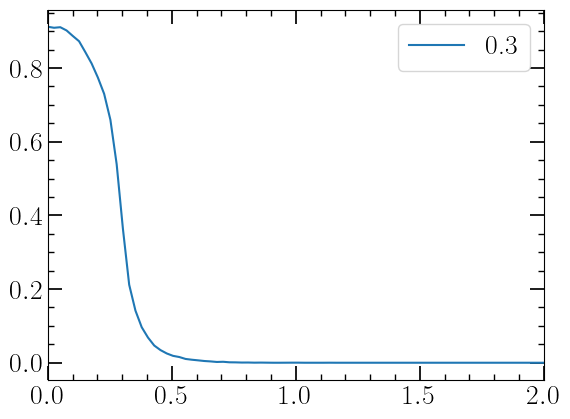

[2.]
[113.]
[115.] 115.0


In [13]:
z_true_arr = np.linspace(0, 2.5, 100)
Ngw_per_z = 10000

plt.figure()

zcuts = [0.3]

Ntot = int(1e5)
N = 1
obs_ngw_from_agn = np.zeros(N)
obs_ngw_from_alt = np.zeros(N)

for k in tqdm(range(N)):
    for zcut in zcuts:
        Pdet_arr = np.zeros_like(z_true_arr)
        for i, redshift_true in enumerate(z_true_arr):
            true_theta, true_phi = sample_spherical_angles(n_samps=Ngw_per_z)
            true_redshift = np.tile(redshift_true, Ngw_per_z)
            true_rcom = COSMO.comoving_distance(true_redshift).value

            true_x, true_y, true_z = spherical2cartesian(true_rcom, true_theta, true_phi)

            v90 = sample_v90(Ngw_per_z, factor=1)
            sig = v90_to_sigma(v90)
            obs_x, obs_y, obs_z = np.random.normal(loc=true_x, scale=sig, size=Ngw_per_z), np.random.normal(loc=true_y, scale=sig, size=Ngw_per_z), np.random.normal(loc=true_z, scale=sig, size=Ngw_per_z)
            obs_rcom, _, _ = cartesian2spherical(obs_x, obs_y, obs_z)
            obs_redshift = fast_z_at_value(COSMO.comoving_distance, obs_rcom * u.Mpc)
            sel = obs_redshift < zcut

            Pdet_arr[i] = np.sum(sel) / Ngw_per_z

        # np.save(f'pdet_z_{zcut}.npy', np.array([z_true_arr, Pdet_arr]))

        plt.plot(z_true_arr, Pdet_arr, label=f'{zcut}')
        # plt.vlines(zcut, 0, 1)

        int_ax = np.linspace(1e-6, 10, 16*1024+1)
        Pdet = CubicSpline(z_true_arr, Pdet_arr, extrapolate=False)(int_ax)
        Pdet[np.isnan(Pdet)] = 0  # NaNs outside extrapolation range changed to zeros

        alpha_agn = romb(Pdet * Z_DIST_AGN(int_ax), dx=np.diff(int_ax)[0])
        alpha_alt = romb(Pdet * Z_DIST_ALT(int_ax), dx=np.diff(int_ax)[0])
        print(alpha_agn, alpha_alt)

    f = np.random.uniform()
    obs_ngw_from_agn[k] = round(alpha_agn * f * Ntot)
    obs_ngw_from_alt[k] = round(alpha_alt * (1 - f) * Ntot)

    # plt.plot(int_ax, Pdet)

plt.xlim(0, 2)
plt.legend()
plt.show()

print(obs_ngw_from_agn)
print(obs_ngw_from_alt)
print(obs_ngw_from_agn + obs_ngw_from_alt, np.sum(obs_ngw_from_agn + obs_ngw_from_alt))

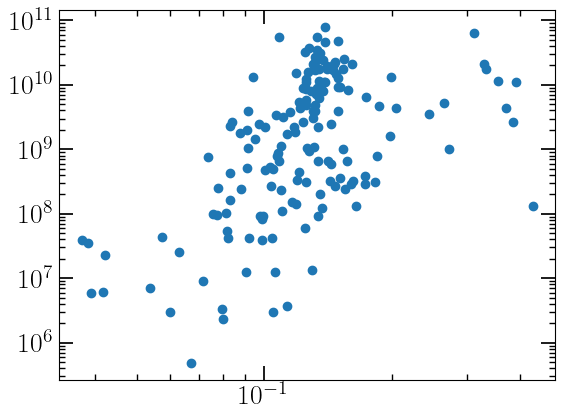

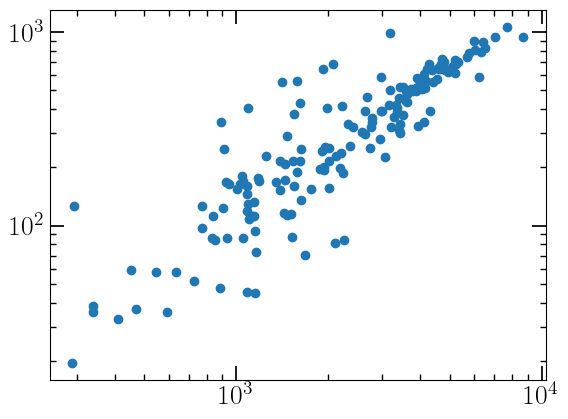

In [ ]:
plt.figure()
plt.scatter(v90_to_sigma(np.array(real_v90s)) / real_meandls, real_v90s)
plt.loglog()
plt.show()

plt.figure()
plt.scatter(real_meandls, v90_to_sigma(real_v90s))
plt.loglog()
plt.show()
